# Path to split

In [1]:
import json

# file_to_split = "c0_million/exp_setting_3/experiment_0/train.json" 
# path = "c0_million/exp_setting_3/experiment_0"

file_to_split = "million_dataset/exp_setting_1/experiment_1/train.json" 
path = "million_dataset/exp_setting_1/experiment_1"

with open(file_to_split) as f:
    data = json.load(f)

In [2]:
def count_transformations_per_split(data):
    transformation_count = {}
    for i in range(len(data)):
        transformation = str(data[i]["transformation_suite"])
        if transformation not in list(transformation_count.keys()):
            transformation_count[transformation] = 0
        transformation_count[transformation] += 1
    
    print("Transformations in the split:", transformation_count)
    print("Total unique transformations:", len(transformation_count))
    print("Total length of the split:", sum(transformation_count.values()))
    print("Total length of the split (verified):", len(data))
    return transformation_count

In [3]:
transformation_count_dict = count_transformations_per_split(data)

Transformations in the split: {"['translate_up']": 111112, "['rot90']": 111111, "['mirror_horizontal']": 111111, "['translate_up', 'translate_up']": 111111, "['rot90', 'rot90']": 111111, "['mirror_horizontal', 'mirror_horizontal']": 111111, "['translate_up', 'mirror_horizontal']": 111111, "['rot90', 'mirror_horizontal']": 111111, "['mirror_horizontal', 'rot90']": 111111}
Total unique transformations: 9
Total length of the split: 1000000
Total length of the split (verified): 1000000


# Calculate subdivisions

In [4]:
transformation_subdividision_100k = {}
transformation_subdivision_250k = {}
transformation_subdivision_500k = {}

transformation_subdivision_1k = {}

for transformation in list(transformation_count_dict.keys()):
    transformation_subdividision_100k[transformation] = transformation_count_dict[transformation] // 10 + 1
    transformation_subdivision_250k[transformation] = transformation_count_dict[transformation] // 4 + 1
    transformation_subdivision_500k[transformation] = transformation_count_dict[transformation] // 2 + 1
    transformation_subdivision_1k[transformation] = transformation_count_dict[transformation] // 1000 + 1

# Allocate into respective splits

In [5]:
splits = {
    "100k": transformation_subdividision_100k,
    "250k": transformation_subdivision_250k,
    "500k": transformation_subdivision_500k,
    "1k": transformation_subdivision_1k
}

split_100k = []
split_250k = []
split_500k = [] 
split_1k = []

current_count = {}

for task in data:
    transformation = str(task["transformation_suite"])
    current_count[transformation] = 1 if transformation not in list(current_count.keys()) else current_count[transformation] + 1
    
    if current_count[transformation] <= splits["100k"][transformation]:
        split_100k.append(task)
    if current_count[transformation] <= splits["250k"][transformation]:
        split_250k.append(task)
    if current_count[transformation] <= splits["500k"][transformation]:
        split_500k.append(task)
    if current_count[transformation] <= splits["1k"][transformation]:
        split_1k.append(task)

In [6]:
count_transformations_per_split(split_100k)

Transformations in the split: {"['translate_up']": 11112, "['rot90']": 11112, "['mirror_horizontal']": 11112, "['translate_up', 'translate_up']": 11112, "['rot90', 'rot90']": 11112, "['mirror_horizontal', 'mirror_horizontal']": 11112, "['translate_up', 'mirror_horizontal']": 11112, "['rot90', 'mirror_horizontal']": 11112, "['mirror_horizontal', 'rot90']": 11112}
Total unique transformations: 9
Total length of the split: 100008
Total length of the split (verified): 100008


{"['translate_up']": 11112,
 "['rot90']": 11112,
 "['mirror_horizontal']": 11112,
 "['translate_up', 'translate_up']": 11112,
 "['rot90', 'rot90']": 11112,
 "['mirror_horizontal', 'mirror_horizontal']": 11112,
 "['translate_up', 'mirror_horizontal']": 11112,
 "['rot90', 'mirror_horizontal']": 11112,
 "['mirror_horizontal', 'rot90']": 11112}

# Save into subfolders

In [7]:
# Save splits to json files 
import os

# Create directories for the splits if they don't exist
for split_size in ["100k", "250k", "500k"]:
    split_path = path + "_" + split_size
    if not os.path.exists(split_path):
        os.makedirs(split_path)

with open(os.path.join(path + "_100k", "train_100k.json"), "w") as f:
    json.dump(split_100k, f)
with open(os.path.join(path + "_250k", "train_250k.json"), "w") as f:
    json.dump(split_250k, f)
with open(os.path.join(path + "_500k", "train_500k.json"), "w") as f:
    json.dump(split_500k, f)

# Copy all of the other files from the original folder to the new folders
import shutil
original_files = os.listdir(path)
for split_size in ["100k", "250k", "500k"]:
    split_path = path + "_" + split_size
    for file in original_files:
        if file != "train.json":
            shutil.copy(os.path.join(path, file), os.path.join(split_path, file))

# Debug

In [19]:
import json
import pandas as pd

exp_setting = 1
experiment = 1

local_folder = "c0_million" if experiment == 0 else "million_dataset 2"
hf_folder = "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/"
# hf_folder = "million_dataset_parquet" 
extension = "parquet"

file = f"{hf_folder}/exp_setting_{exp_setting}/experiment_{experiment}_100k/train.{extension}" 
val_file = f"{hf_folder}/exp_setting_{exp_setting}/experiment_{experiment}_100k/val.{extension}"
val_ood_file = f"{hf_folder}/exp_setting_{exp_setting}/experiment_{experiment}_100k/val_ood.{extension}"
test_file = f"{hf_folder}/exp_setting_{exp_setting}/experiment_{experiment}_100k/test.{extension}"
test_ood_file = f"{hf_folder}/exp_setting_{exp_setting}/experiment_{experiment}_100k/test_ood.{extension}"

if extension == "parquet":
    data = pd.read_parquet(file).to_dict(orient="records")
    val_data = pd.read_parquet(val_file).to_dict(orient="records")
    val_ood_data = pd.read_parquet(val_ood_file).to_dict(orient="records")
    test_data = pd.read_parquet(test_file).to_dict(orient="records")
    test_ood_data = pd.read_parquet(test_ood_file).to_dict(orient="records")
else:
    with open(file) as f:
        data = json.load(f)
    with open(test_file) as f:
        test_data = json.load(f)
    with open(test_ood_file) as f:
        test_ood_data = json.load(f)
    with open(val_file) as f:
        val_data = json.load(f)
    with open(val_ood_file) as f:
        val_ood_data = json.load(f)

count_transformations_per_split(data)
count_transformations_per_split(val_data)
count_transformations_per_split(val_ood_data)
count_transformations_per_split(test_data)
count_transformations_per_split(test_ood_data)

Transformations in the split: {"['translate_up']": 11112, "['rot90']": 11112, "['mirror_horizontal']": 11112, "['translate_up' 'translate_up']": 11112, "['rot90' 'rot90']": 11112, "['mirror_horizontal' 'mirror_horizontal']": 11112, "['translate_up' 'mirror_horizontal']": 11112, "['rot90' 'mirror_horizontal']": 11112, "['mirror_horizontal' 'rot90']": 11112}
Total unique transformations: 9
Total length of the split: 100008
Total length of the split (verified): 100008
Transformations in the split: {"['translate_up']": 112, "['rot90']": 111, "['mirror_horizontal']": 111, "['translate_up' 'translate_up']": 111, "['rot90' 'rot90']": 111, "['mirror_horizontal' 'mirror_horizontal']": 111, "['translate_up' 'mirror_horizontal']": 111, "['rot90' 'mirror_horizontal']": 111, "['mirror_horizontal' 'rot90']": 111}
Total unique transformations: 9
Total length of the split: 1000
Total length of the split (verified): 1000
Transformations in the split: {"['translate_up' 'rot90']": 500, "['rot90' 'transla

{"['translate_up' 'rot90']": 500, "['rot90' 'translate_up']": 500}

In [14]:
test_ood_data[0]["input"]

array([array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 3]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 2, 3]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 3, 2, 3]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 3, 2, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 3, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 3, 1, 1, 3, 3, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 1, 1, 3, 7, 1, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 3, 7, 1, 1, 7, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])], dtype=object)

['rot90' 'translate_up']


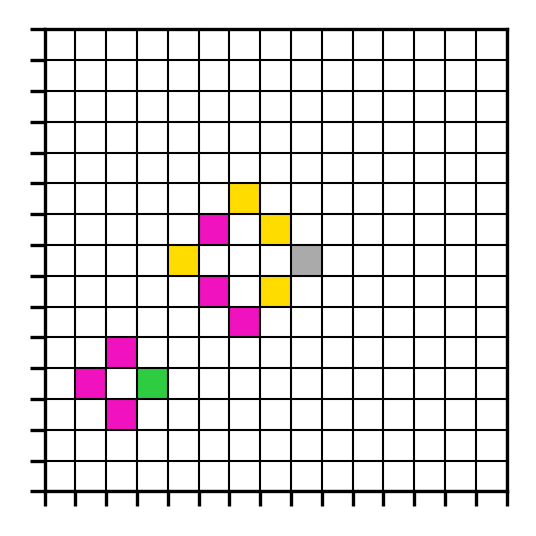

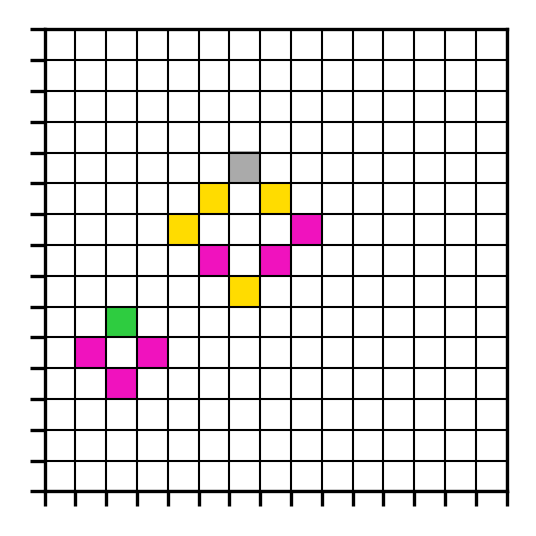

In [22]:
from arcworld.general_utils import plot_grid


id = 929
arr_of_interest = val_ood_data

input = [arr.tolist() for arr in arr_of_interest[id]["input"]]
output = [arr.tolist() for arr in arr_of_interest[id]["output"]]

plot_grid(input, size = (2,2))
plot_grid(output, size = (2,2))
print(arr_of_interest[id]["transformation_suite"])